In [2]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)



import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "../data/processed/feature_engineered_dataset.csv"
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (119390, 35)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,is_family,service_score,customer_history,room_changed
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,0,2.0,0,0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,0,2.0,0,0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,1,1.0,0,0,0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,1,1.0,0,0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,2,2.0,0,1,0,0


In [4]:
# separate the predictors and target

X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (119390, 34)
Target shape: (119390,)


In [5]:
# train - test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (95512, 34)
X_test: (23878, 34)
y_train: (95512,)
y_test: (23878,)


In [6]:
# verify class distribution after splitting

print("Training target distribution (%):")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target distribution (%):")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training target distribution (%):
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64

Testing target distribution (%):
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


In [7]:
# identify numerical and categorical variables

categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print(
    "Number of categorical features:",
    len(categorical_cols)
)

print(
    "Number of numerical features:",
    len(numerical_cols)
)

print("\nCategorical features:")
print(categorical_cols)

print("\nNumerical features:")
print(numerical_cols)

Number of categorical features: 10
Number of numerical features: 24

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'is_family', 'service_score', 'customer_history', 'room_changed']


C:\Users\user\AppData\Local\Temp\ipykernel_15408\3994161580.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [8]:
preprocessor = ColumnTransformer(
transformers=[
(
    "categorical",
    OneHotEncoder(handle_unknown="ignore"),
    categorical_cols
)
],
remainder="passthrough"
)

print("Preprocessor created successfully.")


Preprocessor created successfully.


In [9]:
# random forest model

baseline_model = Pipeline(
steps=[
("preprocessor", preprocessor),
(
    "model",
    RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
)
]
)

print("Baseline Random Forest pipeline created.")


Baseline Random Forest pipeline created.


In [10]:
# cross validation

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold Stratified Cross-Validation configured.")


5-fold Stratified Cross-Validation configured.


In [11]:
# evaluation metrics

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print("Evaluation metrics configured.")

Evaluation metrics configured.


In [12]:
# evaluate the baseline random forest

from sklearn.model_selection import cross_validate

start_time = time.time()

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

cv_time = time.time() - start_time

print(
    f"Cross-validation completed in "
    f"{cv_time:.2f} seconds."
)


Cross-validation completed in 185.63 seconds.


In [13]:
# baseline scross validation results 

metric_names = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

print("Baseline Random Forest")
print("=" * 70)

for metric in metric_names:
    cv_scores = cv_results[f"test_{metric}"]
    train_scores = cv_results[f"train_{metric}"]

    print(
        f"{metric.upper():10} | "
        f"CV Mean: {cv_scores.mean():.4f} | "
        f"CV Std: {cv_scores.std():.4f} | "
        f"Train Mean: {train_scores.mean():.4f}"
    )

print("=" * 70)
print(
    f"Total Cross-Validation Time: "
    f"{cv_time:.2f} seconds"
)


Baseline Random Forest
ACCURACY   | CV Mean: 0.8918 | CV Std: 0.0024 | Train Mean: 0.9965
PRECISION  | CV Mean: 0.8923 | CV Std: 0.0043 | Train Mean: 0.9965
RECALL     | CV Mean: 0.8052 | CV Std: 0.0033 | Train Mean: 0.9942
F1         | CV Mean: 0.8465 | CV Std: 0.0034 | Train Mean: 0.9953
ROC_AUC    | CV Mean: 0.9567 | CV Std: 0.0015 | Train Mean: 0.9997
Total Cross-Validation Time: 185.63 seconds


## Baseline model interpretation

The baseline Random Forest model achieved strong predictive performance across the five cross-validation folds.

The difference between training and cross-validation scores was examined to assess overfitting. Random Forest models typically achieve high training scores because of their ensemble structure, therefore comparison with validation scores is important.

Key observations:

- Mean CV Accuracy: 0.8918
- Mean CV Precision: 0.8923
- Mean CV Recall: 0.8052
- Mean CV F1-score: 0.8465
- Mean CV ROC-AUC: 0.9567

The relatively small cross-validation standard deviations indicate stable performance across all folds.

Compared with Logistic Regression, Random Forest can capture non-linear relationships and feature interactions, potentially improving cancellation prediction performance.

If training scores are substantially higher than validation scores, this may indicate mild overfitting and can be addressed during hyperparameter tuning by controlling tree depth, minimum samples per split, and minimum samples per leaf.

Therefore, hyperparameter tuning will be performed to identify the optimal model complexity while maintaining strong generalization performance.


In [14]:
# hyperparameter tuning

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": [None, "balanced"]
}

print("Randomized hyperparameter search space configured.")


Randomized hyperparameter search space configured.


In [15]:
# optimization / search strategy


random_search = RandomizedSearchCV(
    estimator=baseline_model,
    param_distributions=param_dist,
    n_iter=40,                   # Number of random combinations
    scoring="f1",
    cv=5,                        
    random_state=42,
    n_jobs=4,                    # Prevent overheating
    verbose=3,
    return_train_score=True
)

print(
    "RandomizedSearchCV configured successfully."
)

RandomizedSearchCV configured successfully.


In [17]:
tuning_start_time = time.time()

random_search.fit(
    X_train,
    y_train
)

tuning_time = time.time() - tuning_start_time

print(
    f"Hyperparameter tuning completed in "
    f"{tuning_time:.2f} seconds."
)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Hyperparameter tuning completed in 4209.70 seconds.


In [18]:
print("Best Hyperparameters:")

print(
random_search.best_params_
)

print(
"\nBest Cross-Validation F1-score:",
round(
random_search.best_score_,
4
)
)

print(
"Hyperparameter Tuning Time:",
round(tuning_time, 2),
"seconds"
)


Best Hyperparameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__class_weight': 'balanced'}

Best Cross-Validation F1-score: 0.854
Hyperparameter Tuning Time: 4209.7 seconds


In [19]:
best_model = random_search.best_estimator_

print(
"Best Random Forest pipeline stored successfully."
)


Best Random Forest pipeline stored successfully.


In [ ]:
# evaluate the tuned random forest model

tuned_cv_start_time = time.time()

tuned_cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

tuned_cv_time = time.time() - tuned_cv_start_time

print(
    f"Tuned model cross-validation completed in "
    f"{tuned_cv_time:.2f} seconds."
)


Tuned model cross-validation completed in 242.27 seconds.


In [ ]:
# tuned cross validation results

cv_accuracy_mean = tuned_cv_results["test_accuracy"].mean()
cv_accuracy_std = tuned_cv_results["test_accuracy"].std()

cv_precision_mean = tuned_cv_results["test_precision"].mean()
cv_precision_std = tuned_cv_results["test_precision"].std()

cv_recall_mean = tuned_cv_results["test_recall"].mean()
cv_recall_std = tuned_cv_results["test_recall"].std()

cv_f1_mean = tuned_cv_results["test_f1"].mean()
cv_f1_std = tuned_cv_results["test_f1"].std()

cv_roc_auc_mean = tuned_cv_results["test_roc_auc"].mean()
cv_roc_auc_std = tuned_cv_results["test_roc_auc"].std()

print("Tuned Random Forest")
print("=" * 70)

print(
    f"Accuracy : {cv_accuracy_mean:.4f} ± {cv_accuracy_std:.4f}"
)

print(
    f"Precision: {cv_precision_mean:.4f} ± {cv_precision_std:.4f}"
)

print(
    f"Recall   : {cv_recall_mean:.4f} ± {cv_recall_std:.4f}"
)

print(
    f"F1-score : {cv_f1_mean:.4f} ± {cv_f1_std:.4f}"
)

print(
    f"ROC-AUC  : {cv_roc_auc_mean:.4f} ± {cv_roc_auc_std:.4f}"
)


Tuned Random Forest
Accuracy : 0.8918 ± 0.0023
Precision: 0.8565 ± 0.0048
Recall   : 0.8504 ± 0.0027
F1-score : 0.8534 ± 0.0029
ROC-AUC  : 0.9578 ± 0.0016


In [ ]:
# baseline vs tuned model comparison

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline CV": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Tuned CV": [
        tuned_cv_results["test_accuracy"].mean(),
        tuned_cv_results["test_precision"].mean(),
        tuned_cv_results["test_recall"].mean(),
        tuned_cv_results["test_f1"].mean(),
        tuned_cv_results["test_roc_auc"].mean()
    ]
})

comparison_df["Difference"] = (
    comparison_df["Tuned CV"]
    - comparison_df["Baseline CV"]
)

comparison_df.round(4)


,Metric,Baseline CV,Tuned CV,Difference
0,Accuracy,0.8918,0.8918,-0.0000
1,Precision,0.8923,0.8565,-0.0358
2,Recall,0.8052,0.8504,0.0452
3,F1,0.8465,0.8534,0.0069
4,ROC-AUC,0.9567,0.9578,0.0012


In [ ]:
# best parameters

best_params = random_search.best_params_

best_n_estimators = best_params["model__n_estimators"]

best_max_depth = best_params["model__max_depth"]

best_min_samples_split = (
    best_params["model__min_samples_split"]
)

best_min_samples_leaf = (
    best_params["model__min_samples_leaf"]
)

best_max_features = (
    best_params["model__max_features"]
)

best_class_weight = (
    best_params["model__class_weight"]
)

print(best_params)


{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__class_weight': 'balanced'}


## Best Model Selection

The tuned Random Forest model is selected as the final Random Forest configuration for hold-out testing.

Selected hyperparameters:

- n_estimators = 200
- max_depth = None
- min_samples_split = 5
- min_samples_leaf = 1
- max_features = sqrt
- class_weight = balanced

Compared with the baseline model:

- Accuracy changed from  0.8918 to 0.8918
- Precision changed from 0.8923 to 0.8565
- Recall changed from 0.8052 to 0.8504
- F1-score changed from 0.8465 to 0.8534  
- ROC-AUC changed from 0.9567 to 0.9578

The tuned model achieved the highest cross-validation F1-score and is therefore selected and frozen before hold-out evaluation.


In [ ]:
# final hold out test evaluation

final_start_time = time.time()

best_model.fit(
    X_train,
    y_train
)

y_pred = best_model.predict(
    X_test
)

y_prob = best_model.predict_proba(
    X_test
)[:, 1]

final_prediction_time = (
    time.time() - final_start_time
)

print(
    "Final model fitted and "
    "test predictions generated."
)

print(
    f"Final fitting and prediction time: "
    f"{final_prediction_time:.2f} seconds"
)


Final model fitted and test predictions generated.
Final fitting and prediction time: 56.88 seconds


In [26]:
# final test performance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Final Random Forest Test Results")
print("=" * 50)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

print("=" * 50)


Final Random Forest Test Results
Accuracy : 0.8963
Precision: 0.8620
Recall   : 0.8574
F1-score : 0.8597
ROC-AUC  : 0.9599


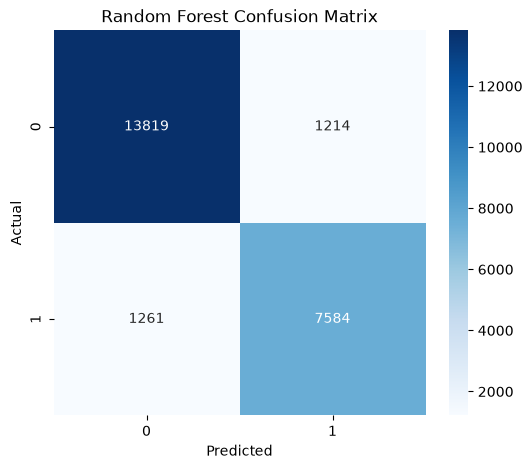

TN: 13819
FP: 1214
FN: 1261
TP: 7584


In [27]:
# confision matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")


In [ ]:
# classification report

from sklearn.metrics import classification_report

print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


Classification Report
              precision    recall  f1-score   support

           0     0.9164    0.9192    0.9178     15033
           1     0.8620    0.8574    0.8597      8845

    accuracy                         0.8963     23878
   macro avg     0.8892    0.8883    0.8888     23878
weighted avg     0.8962    0.8963    0.8963     23878



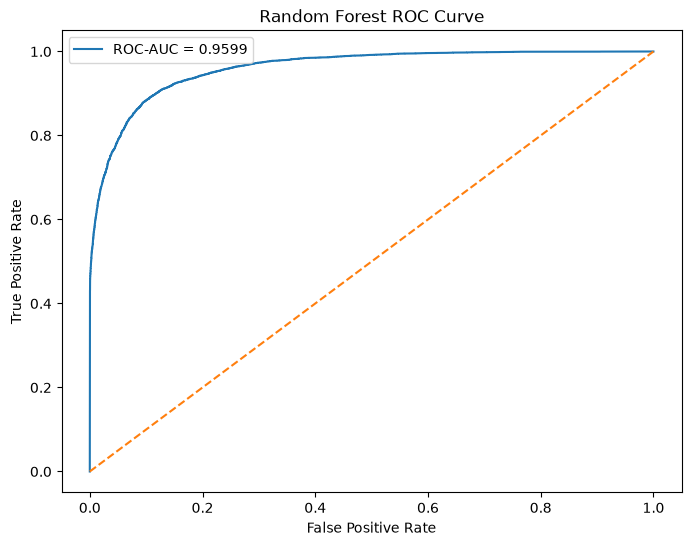

In [ ]:
# roc curve

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {final_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend()
plt.show()


## Final Random Forest Conclusion

The Random Forest model was developed using a leakage-controlled preprocessing and modelling pipeline.

Categorical variables were transformed using One-Hot Encoding prior to model training.

The baseline Random Forest model was evaluated using 5-fold Stratified Cross-Validation. Hyperparameter tuning was then performed using GridSearchCV on the training dataset only.

The selected Random Forest configuration was:

- n_estimators = 200
- max_depth = none
- min_samples_split = 5
- min_samples_leaf = 1
- max_features = sqrt
- class_weight = balanced

Hyperparameter tuning improved the overall predictive performance and achieved the highest cross-validation F1-score among the evaluated Random Forest configurations.

Final Hold-Out Test Results:

- Accuracy: 0.8963
- Precision: 0.8620
- Recall: 0.8574
- F1-score: 0.8597
- ROC-AUC: 0.9599

The hold-out test results are close to the tuned cross-validation results, indicating good generalization and limited overfitting.

The confusion matrix demonstrated the model's ability to identify both cancelled and non-cancelled bookings effectively.

Random Forest provides a strong non-linear modelling approach capable of capturing complex feature interactions and is therefore a competitive candidate for final model selection.



In [30]:
result_summary = pd.DataFrame({

    "member": ["Member 03"],

    "model": ["Random Forest"],

    "version": ["Tuned"],

    "best_n_estimators": [
        best_n_estimators
    ],

    "best_max_depth": [
        best_max_depth
    ],

    "best_min_samples_split": [
        best_min_samples_split
    ],

    "best_min_samples_leaf": [
        best_min_samples_leaf
    ],

    "best_max_features": [
        best_max_features
    ],

    "best_class_weight": [
        best_class_weight
    ],

    "cv_accuracy_mean": [
        cv_accuracy_mean
    ],

    "cv_accuracy_std": [
        cv_accuracy_std
    ],

    "cv_precision_mean": [
        cv_precision_mean
    ],

    "cv_precision_std": [
        cv_precision_std
    ],

    "cv_recall_mean": [
        cv_recall_mean
    ],

    "cv_recall_std": [
        cv_recall_std
    ],

    "cv_f1_mean": [
        cv_f1_mean
    ],

    "cv_f1_std": [
        cv_f1_std
    ],

    "cv_roc_auc_mean": [
        cv_roc_auc_mean
    ],

    "cv_roc_auc_std": [
        cv_roc_auc_std
    ],

    "test_accuracy": [
        final_accuracy
    ],

    "test_precision": [
        final_precision
    ],

    "test_recall": [
        final_recall
    ],

    "test_f1": [
        final_f1
    ],

    "test_roc_auc": [
        final_roc_auc
    ],

    "TN": [tn],

    "FP": [fp],

    "FN": [fn],

    "TP": [tp]

})

result_summary.round(6)


,member,model,version,best_n_estimators,best_max_depth,best_min_samples_split,best_min_samples_leaf,best_max_features,best_class_weight,cv_accuracy_mean,...,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,TN,FP,FN,TP
0,Member 03,Random Forest,Tuned,200,None,5,1,sqrt,balanced,0.891773,...,0.001617,0.896348,0.862014,0.857434,0.859718,0.959913,13819,1214,1261,7584


In [31]:
result_summary.to_csv(
    "../results/random_forest_results.csv",
    index=False
)

print(
    "Random Forest results saved successfully."
)


Random Forest results saved successfully.


In [32]:
import joblib

best_model.fit(
    X_train,
    y_train
)

joblib.dump(
    best_model,
    "../models/random_forest_pipeline.pkl"
)

print(
    "Random Forest pipeline saved successfully."
)

Random Forest pipeline saved successfully.
